# CSCI E-89 Assignment 03 — Problem 5

**Susana Waiha S. Fox**

This notebook independently builds the FashionMNIST image classifier workflow described in the assignment and the chapter reference. Training and validation data are split from the 60,000-image training set; the 10,000-image test set remains separate and is not used during training or validation.

## Load FashionMNIST, scale images to float tensors, and create the fixed 55,000/5,000 split plus separate training, validation, and test loaders. This cell corresponds to `prob5_codex/01_data_setup.py`.

In [1]:
"""Load FashionMNIST, apply tensor conversion, and make seeded data loaders."""
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

SEED = 42
BATCH_SIZE = 32

def setup_data(root="datasets"):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
    combined = torchvision.datasets.FashionMNIST(
        root=root, train=True, download=True, transform=transform
    )
    test_data = torchvision.datasets.FashionMNIST(
        root=root, train=False, download=True, transform=transform
    )
    split_generator = torch.Generator().manual_seed(SEED)
    train_data, valid_data = torch.utils.data.random_split(
        combined, [55_000, 5_000], generator=split_generator
    )
    loader_generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        train_data, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator
    )
    valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
    return combined, train_data, valid_data, test_data, train_loader, valid_loader, test_loader

if __name__ == "__main__":
    data = setup_data()
    print(f"Train: {len(data[1]):,}; validation: {len(data[2]):,}; test: {len(data[3]):,}")


Train: 55,000; validation: 5,000; test: 10,000


## Define the reference multilayer perceptron with 784 inputs, hidden layers of 300 and 100 ReLU units, and 10 output scores. This cell corresponds to `prob5_codex/02_model.py`.

In [2]:
"""Define the reference 784→300→100→10 image classifier."""
import torch.nn as nn

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=784, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2), nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, images):
        return self.mlp(images)


## Train with cross-entropy and SGD at learning rate 0.1, measuring training and validation accuracy after each epoch. This cell corresponds to `prob5_codex/03_train_model.py`.

In [3]:
"""Train with cross-entropy and SGD, recording accuracy after each epoch."""
import json
from pathlib import Path
import torch
from torch import nn


EPOCHS = 10
LEARNING_RATE = 0.1

def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model(train_loader, valid_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE,
                output_dir="artifacts"):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    model = ImageClassifier().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    history = {"train_accuracy": [], "valid_accuracy": [], "epochs": epochs,
               "learning_rate": learning_rate, "seed": 42}
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss_fn(model(images), labels).backward()
            optimizer.step()
        train_acc = evaluate_accuracy(model, train_loader, device)
        valid_acc = evaluate_accuracy(model, valid_loader, device)
        history["train_accuracy"].append(train_acc)
        history["valid_accuracy"].append(valid_acc)
        print(f"Epoch {epoch + 1:02d}/{epochs}: train accuracy={train_acc:.4f}; validation accuracy={valid_acc:.4f}")
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), output / "prob5_model_weights.pt")
    (output / "prob5_history.json").write_text(json.dumps(history, indent=2) + "\n")
    return model, history, device


## Plot the training accuracy recorded at each epoch. This cell corresponds to `prob5_codex/04_plot_training_accuracy.py`.

In [4]:
"""Plot the recorded training accuracy by epoch."""
from pathlib import Path
import matplotlib.pyplot as plt

def plot_training_accuracy(history, output_path="artifacts/prob5_training_accuracy.png"):
    epochs = range(1, len(history["train_accuracy"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, history["train_accuracy"], marker="o", label="Training")
    ax.set(title="FashionMNIST Training Accuracy", xlabel="Epoch", ylabel="Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150)
    plt.show()
    return fig


## Show example validation images with predicted and true class names. This cell corresponds to `prob5_codex/05_predict_examples.py`.

In [5]:
"""Display several validation images with predicted and true class labels."""
import matplotlib.pyplot as plt
import torch


def show_example_predictions(model, dataset, class_names, device, count=6):
    model.eval()
    images, labels = zip(*(dataset[i] for i in range(count)))
    batch = torch.stack(images).to(device)
    with torch.no_grad():
        predictions = model(batch).argmax(dim=1).cpu().tolist()
    fig, axes = plt.subplots(1, count, figsize=(2.2 * count, 3))
    for ax, image, label, prediction in zip(axes, images, labels, predictions):
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(f"Pred: {class_names[prediction]}\nTrue: {class_names[label]}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()
    return fig, predictions


## Run the workflow

The random seed is fixed at 42. The test loader is prepared for separation and reproducibility but remains untouched by model selection and reporting here; final reported performance is on the validation set.

In [6]:
combined, train_data, valid_data, test_data, train_loader, valid_loader, test_loader = setup_data()
class_names = combined.classes
print(f"Train: {len(train_data):,}; validation: {len(valid_data):,}; test: {len(test_data):,}")

Train: 55,000; validation: 5,000; test: 10,000


In [7]:
model, history, device = train_model(train_loader, valid_loader, epochs=10, learning_rate=0.1)

Epoch 01/10: train accuracy=0.8556; validation accuracy=0.8422


Epoch 02/10: train accuracy=0.8562; validation accuracy=0.8516


Epoch 03/10: train accuracy=0.8808; validation accuracy=0.8670


Epoch 04/10: train accuracy=0.8710; validation accuracy=0.8538


Epoch 05/10: train accuracy=0.8919; validation accuracy=0.8676


Epoch 06/10: train accuracy=0.8944; validation accuracy=0.8726


Epoch 07/10: train accuracy=0.8976; validation accuracy=0.8704


Epoch 08/10: train accuracy=0.8913; validation accuracy=0.8658


Epoch 09/10: train accuracy=0.9002; validation accuracy=0.8720


Epoch 10/10: train accuracy=0.9172; validation accuracy=0.8864


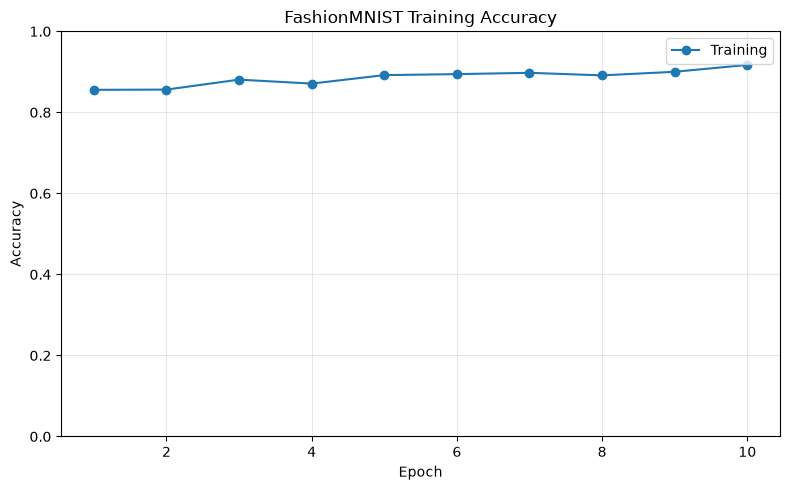

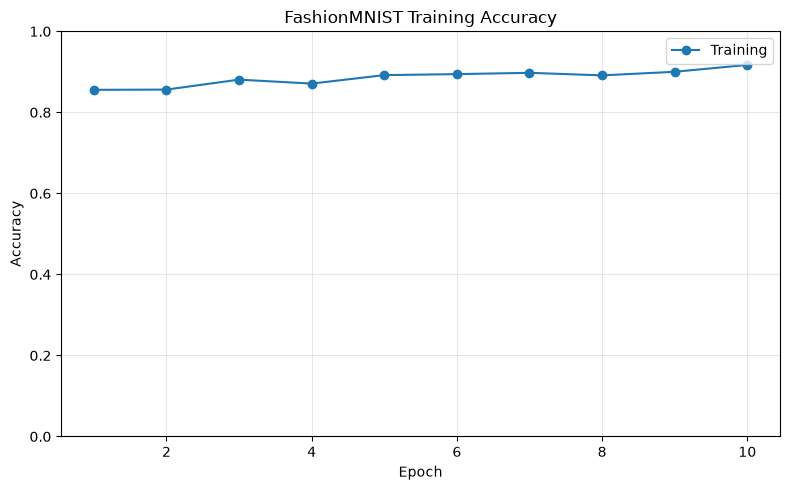

In [8]:
plot_training_accuracy(history)

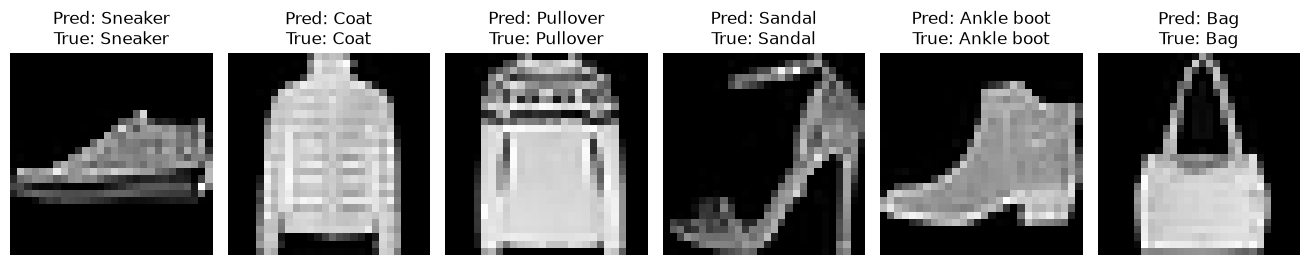

Predictions: ['Sneaker', 'Coat', 'Pullover', 'Sandal', 'Ankle boot', 'Bag']


In [9]:
fig, predictions = show_example_predictions(model, valid_data, class_names, device)
print("Predictions:", [class_names[index] for index in predictions])

In [10]:
print(f"Final training accuracy: {history['train_accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_accuracy'][-1]:.4f}")

Final training accuracy: 0.9172
Final validation accuracy: 0.8864
